In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Exam_Score.csv")
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


In [4]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
course,0
study_hours,0
class_attendance,0
internet_access,0
sleep_hours,0
sleep_quality,0
study_method,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,10000.504600,20.473300,4.007604,70.017365,7.00856,62.513225
std,5773.654959,2.284458,2.308313,17.282262,1.73209,18.908491
min,1.000000,17.000000,0.080000,40.600000,4.10000,19.599000
25%,5000.750000,18.000000,2.000000,55.100000,5.50000,48.800000
50%,10000.500000,20.000000,4.040000,69.900000,7.00000,62.600000
75%,15000.250000,22.000000,6.000000,85.000000,8.50000,76.300000
max,20001.000000,24.000000,7.910000,99.400000,9.90000,100.000000


In [7]:
cat_cols = ['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']
cont_cols = ['age', 'study_hours', 'class_attendance', 'sleep_hours', 'exam_score']

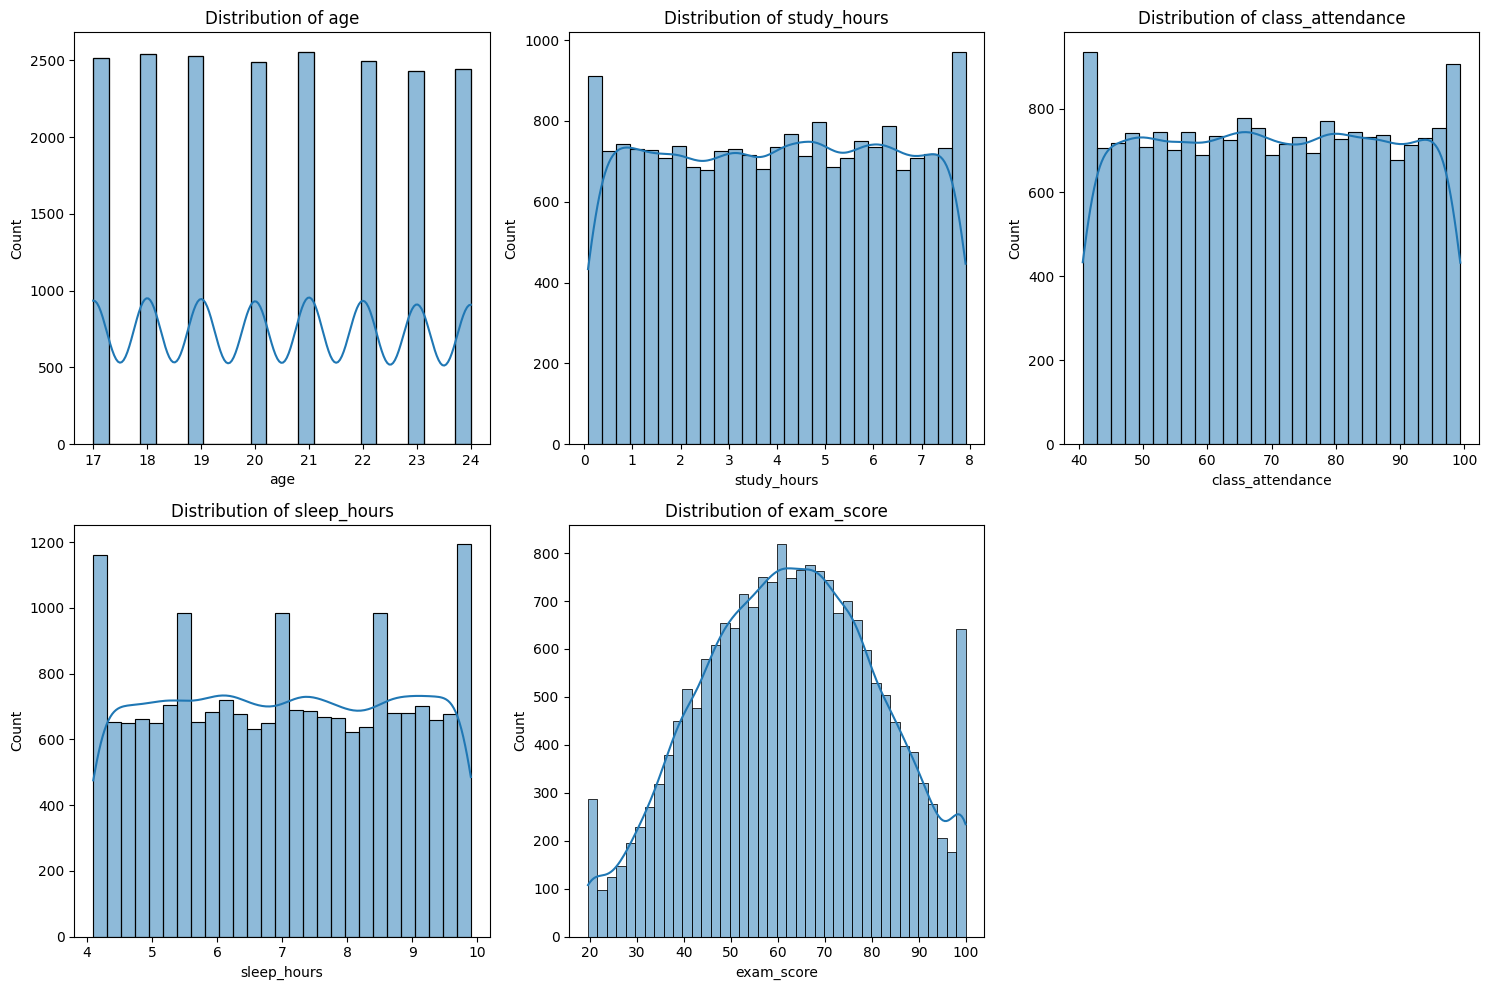

In [8]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(cont_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

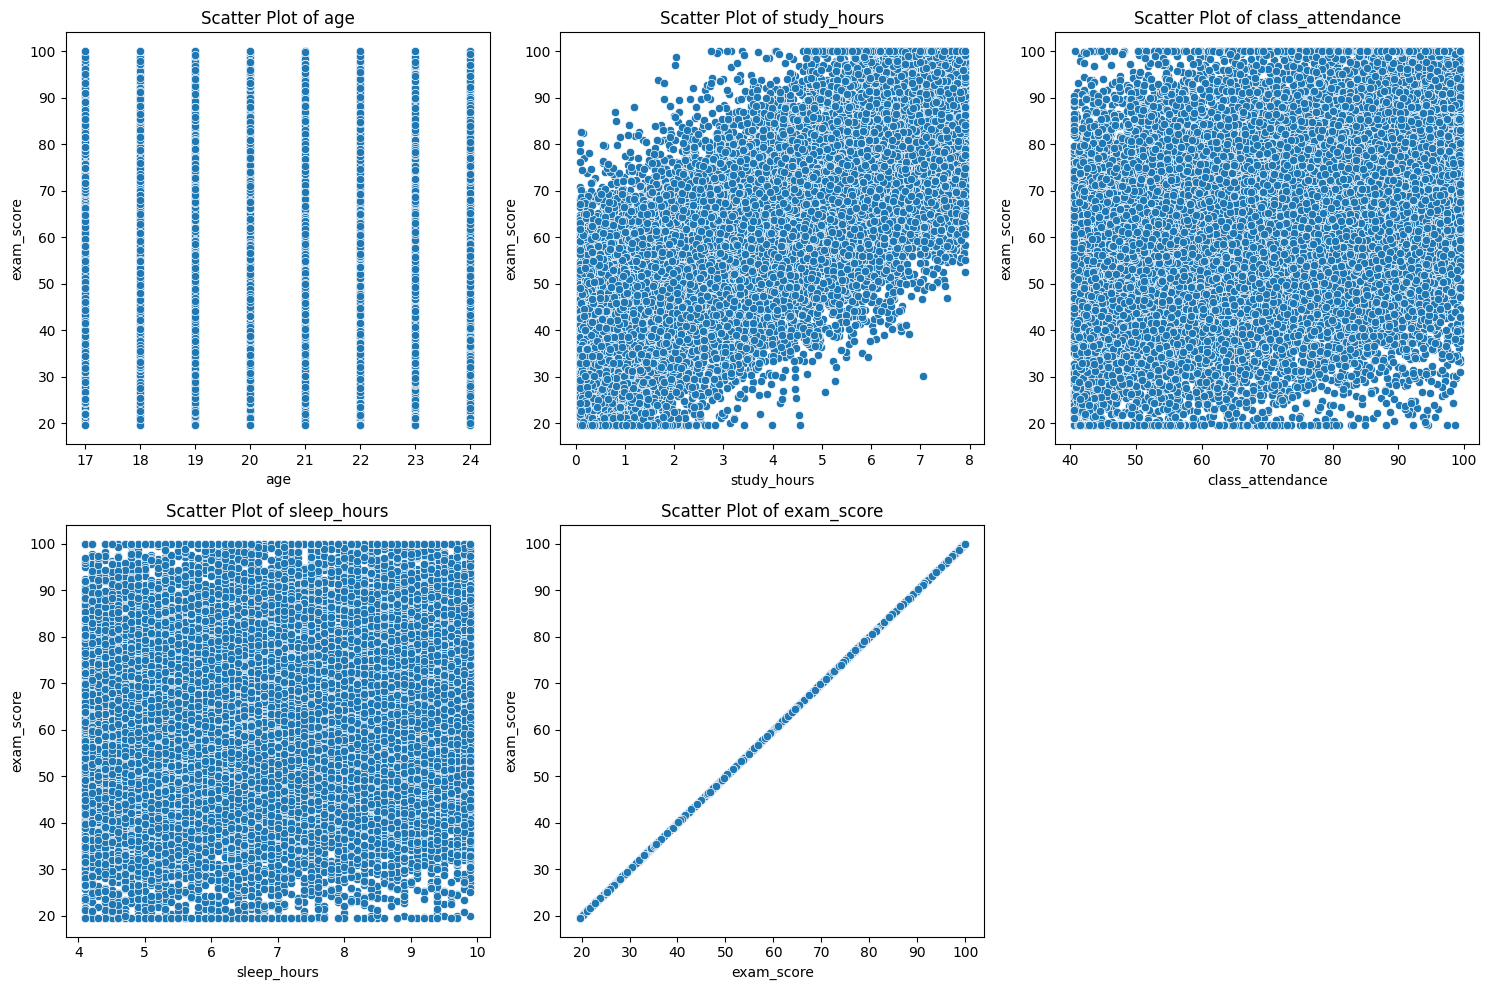

In [9]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(cont_cols):
    plt.subplot(2, 3, i + 1)
    sns.scatterplot(x = df[col], y= df['exam_score'])
    plt.title(f'Scatter Plot of {col}')
plt.tight_layout()
plt.show()

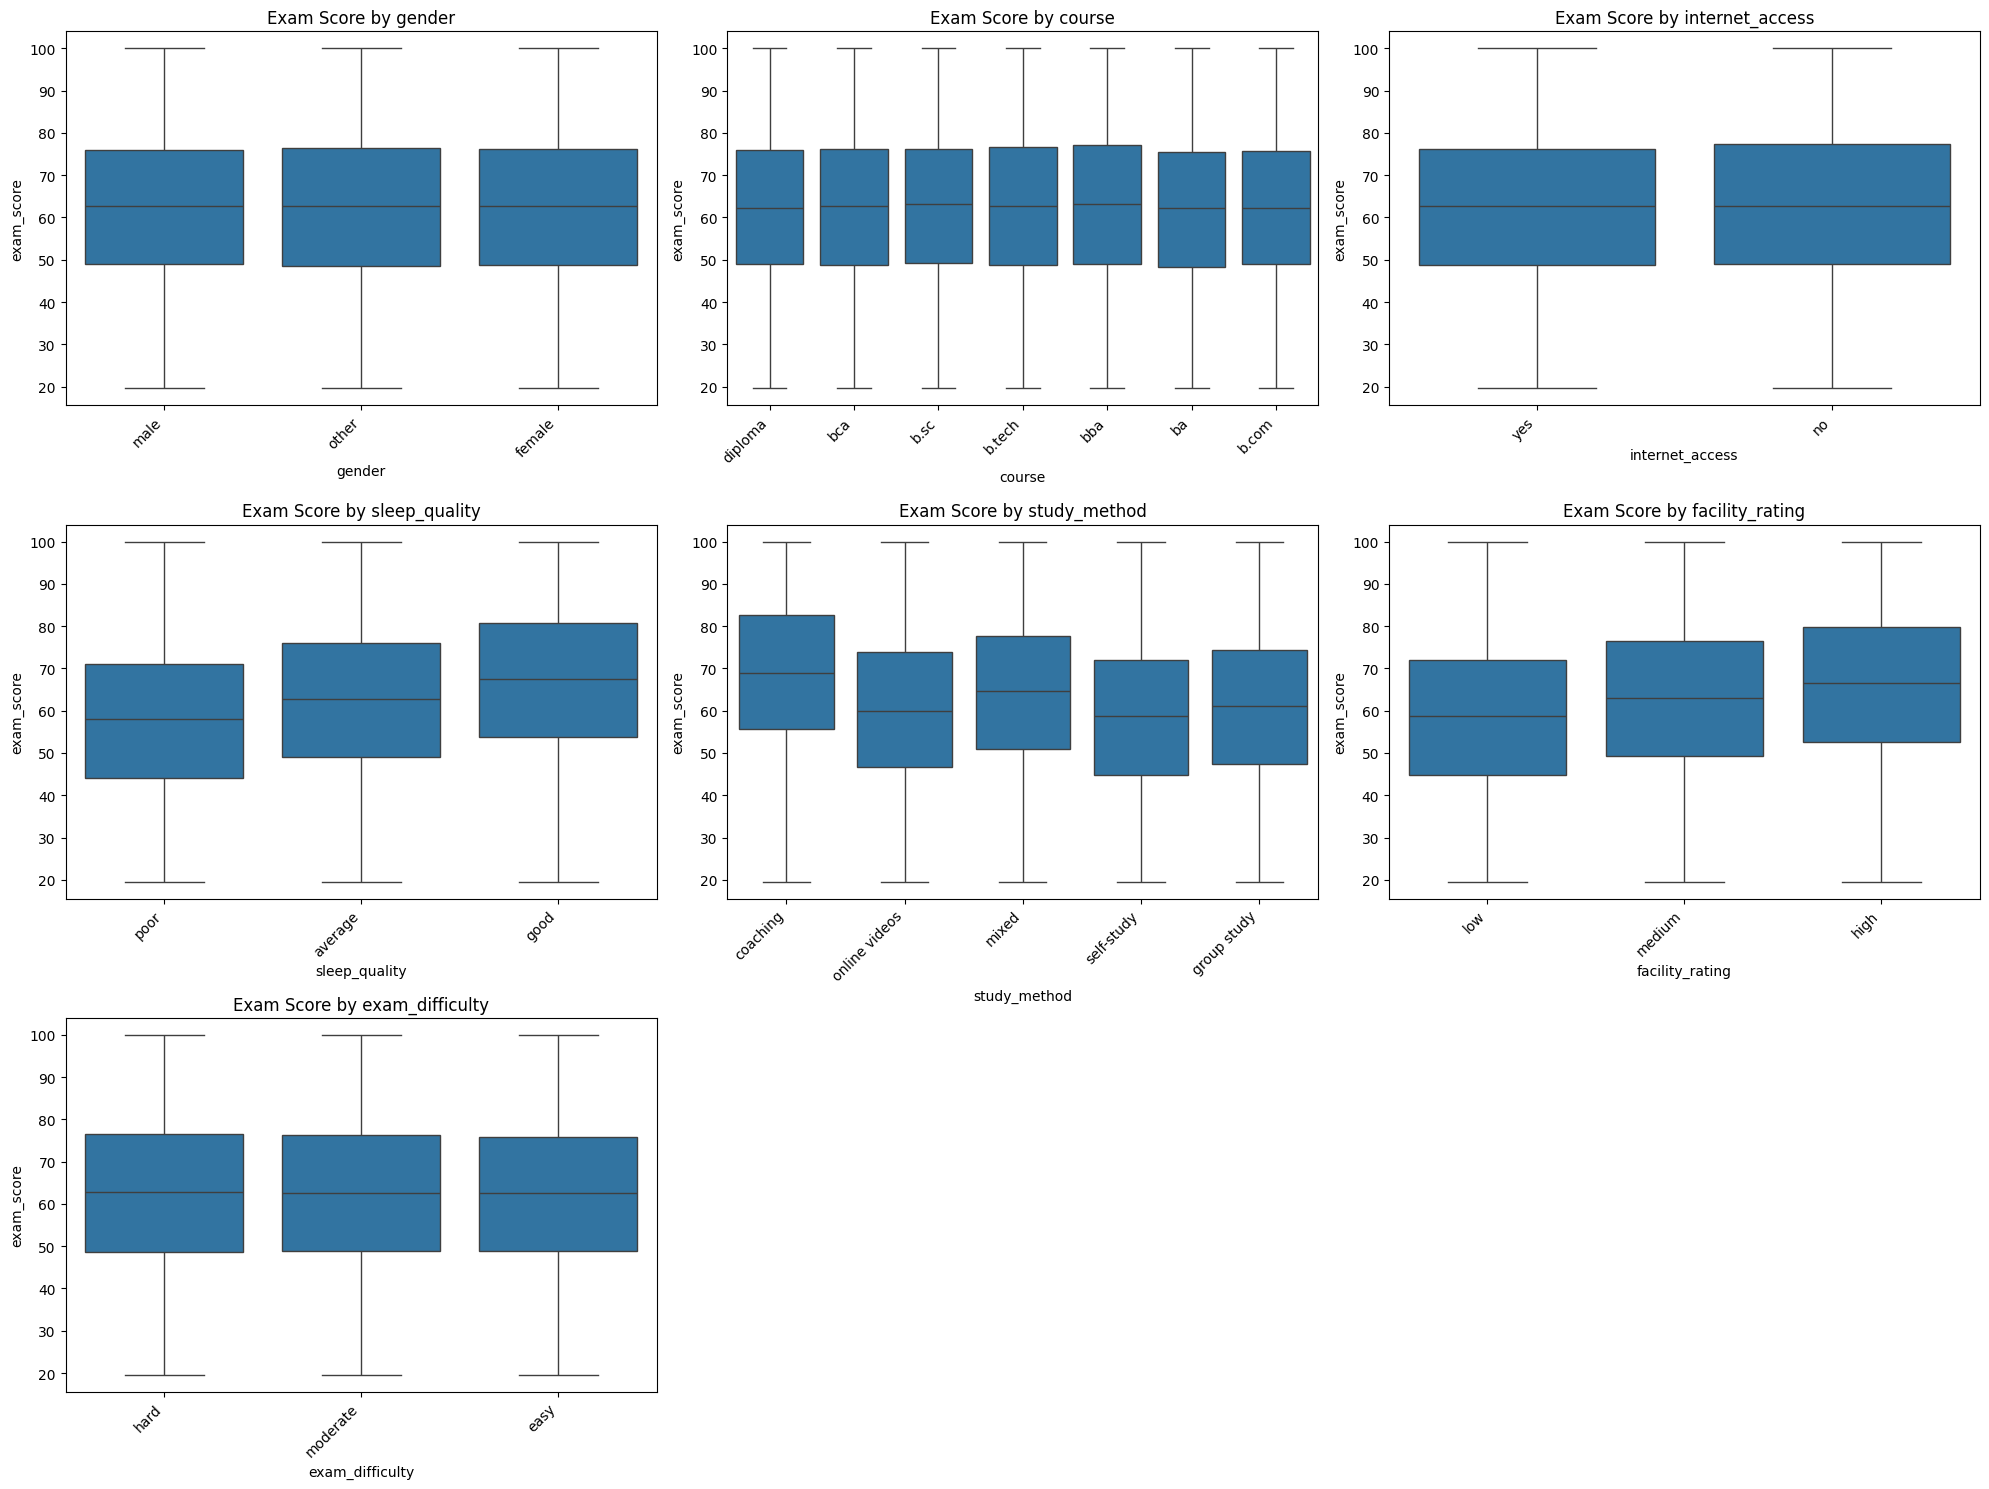

In [10]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(cat_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed based on number of cat_cols
    sns.boxplot(x=col, y='exam_score', data=df)
    plt.title(f'Exam Score by {col}')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

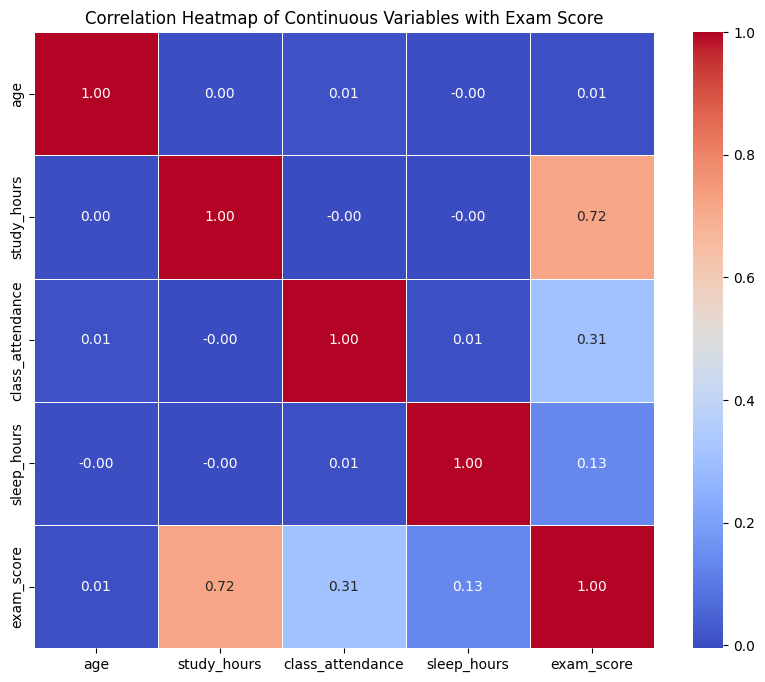

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[cont_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Continuous Variables with Exam Score')
plt.show()

### Pearson Correlation Test for Continuous Columns vs. Exam Score

Pearson correlation measures the linear relationship between two continuous variables. A coefficient close to 1 indicates a strong positive linear relationship, close to -1 indicates a strong negative linear relationship, and close to 0 indicates no linear relationship. The p-value helps determine the statistical significance of this correlation.

In [12]:
from scipy.stats import pearsonr

print("Pearson Correlation with Exam Score:")
cont_independent_cols = [col for col in cont_cols if col != 'exam_score']

for col in cont_independent_cols:
    correlation, p_value = pearsonr(df[col], df['exam_score'])
    print(f"  {col}: Correlation = {correlation:.3f}, P-value = {p_value:.3f}")
    if p_value < 0.05:
        print(f"    (Statistically significant at alpha = 0.05)")
    else:
        print(f"    (Not statistically significant at alpha = 0.05)")

Pearson Correlation with Exam Score:
  age: Correlation = 0.007, P-value = 0.356
    (Not statistically significant at alpha = 0.05)
  study_hours: Correlation = 0.718, P-value = 0.000
    (Statistically significant at alpha = 0.05)
  class_attendance: Correlation = 0.309, P-value = 0.000
    (Statistically significant at alpha = 0.05)
  sleep_hours: Correlation = 0.133, P-value = 0.000
    (Statistically significant at alpha = 0.05)


### ANOVA Test for Categorical Columns vs. Exam Score

ANOVA (Analysis of Variance) is used to determine whether there are any statistically significant differences between the means of two or more independent groups (categories) on a continuous dependent variable (`exam_score`). A low p-value (typically less than 0.05) indicates that there is a significant difference between the means of at least two groups.

In [13]:
from scipy.stats import f_oneway

print("ANOVA Test for Categorical Columns vs. Exam Score:")
for col in cat_cols:
    # Get unique categories
    categories = df[col].unique()
    # Create a list of exam scores for each category
    groups = [df['exam_score'][df[col] == cat] for cat in categories]

    f_statistic, p_value = f_oneway(*groups)
    print(f"  {col}: F-statistic = {f_statistic:.3f}, P-value = {p_value:.3f}")
    if p_value < 0.05:
        print(f"    (Statistically significant at alpha = 0.05)")
    else:
        print(f"    (Not statistically significant at alpha = 0.05)")

ANOVA Test for Categorical Columns vs. Exam Score:
  gender: F-statistic = 0.191, P-value = 0.826
    (Not statistically significant at alpha = 0.05)
  course: F-statistic = 0.614, P-value = 0.719
    (Not statistically significant at alpha = 0.05)
  internet_access: F-statistic = 1.225, P-value = 0.268
    (Not statistically significant at alpha = 0.05)
  sleep_quality: F-statistic = 411.793, P-value = 0.000
    (Statistically significant at alpha = 0.05)
  study_method: F-statistic = 180.527, P-value = 0.000
    (Statistically significant at alpha = 0.05)
  facility_rating: F-statistic = 273.766, P-value = 0.000
    (Statistically significant at alpha = 0.05)
  exam_difficulty: F-statistic = 0.237, P-value = 0.789
    (Not statistically significant at alpha = 0.05)


 1   age               20000 non-null  int64 ❌

 2   gender            20000 non-null  object ❌

 3   course            20000 non-null  object ❌

 4   study_hours       20000 non-null  float64 ✅

 5   class_attendance  20000 non-null  float64 ✅

 6   internet_access   20000 non-null  object ❌

 7   sleep_hours       20000 non-null  float64 ✅

 8   sleep_quality     20000 non-null  object ✅

 9   study_method      20000 non-null  object ✅

 10  facility_rating   20000 non-null  object ✅

 11  exam_difficulty   20000 non-null  object ❌

 12  exam_score        20000 non-null  float64 🦖

In [14]:
significant_cols = [
    'study_hours',
    'class_attendance',
    'sleep_hours',
    'sleep_quality',
    'study_method',
    'facility_rating'
]

print('Significant Columns:', significant_cols)

Significant Columns: ['study_hours', 'class_attendance', 'sleep_hours', 'sleep_quality', 'study_method', 'facility_rating']


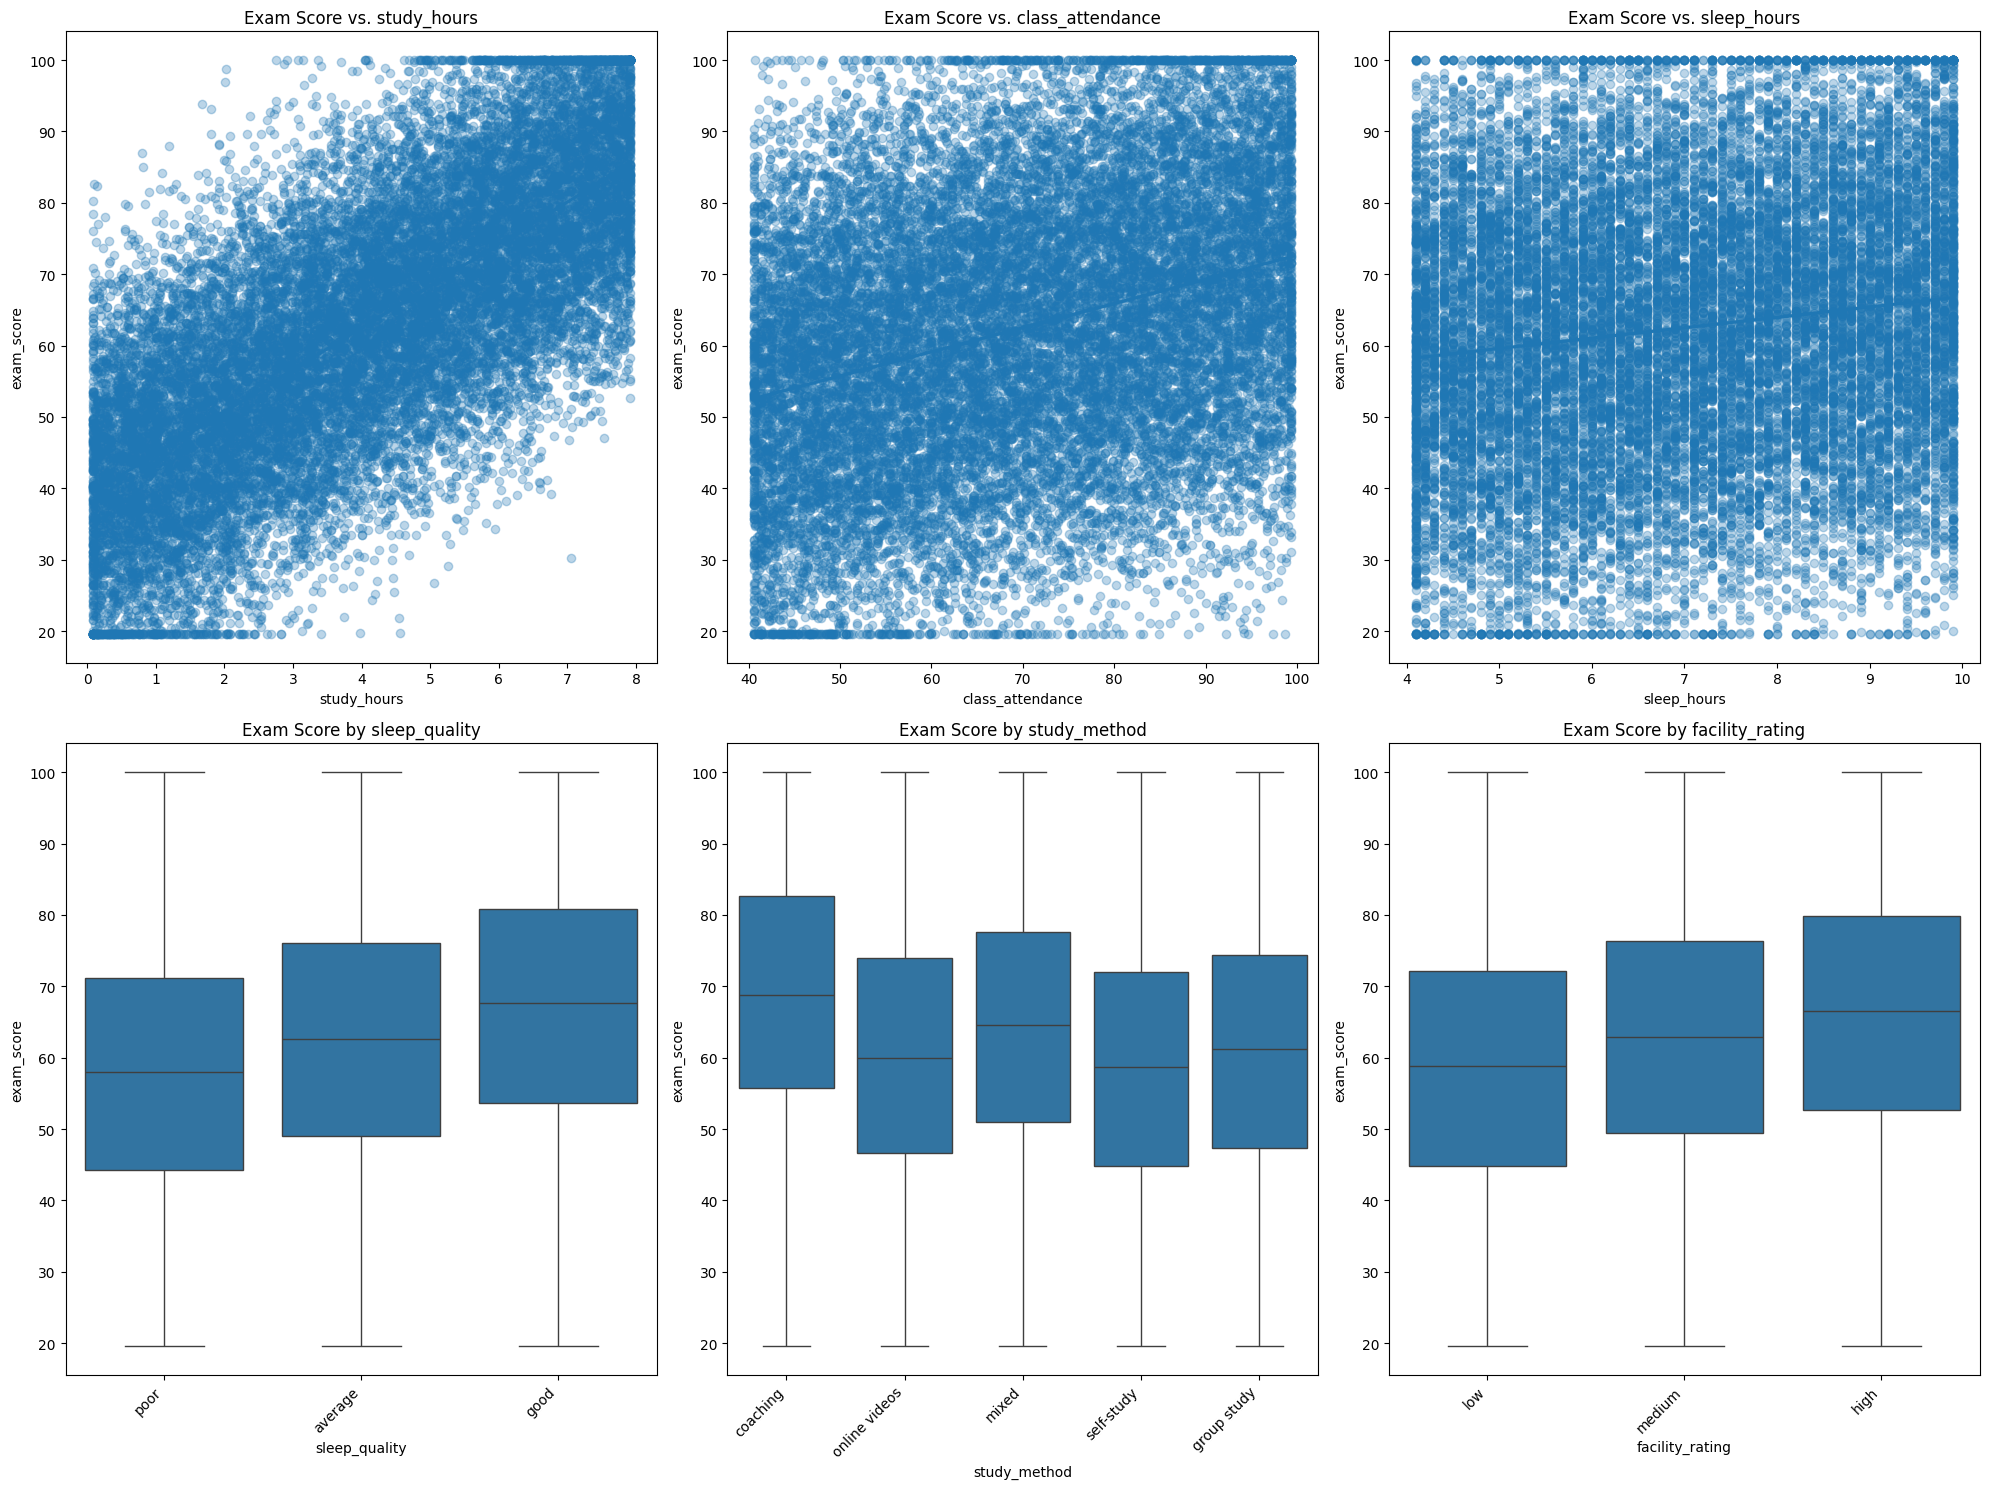

In [15]:
plt.figure(figsize=(20, 15))
plot_idx = 1

# Visualize continuous significant columns
for col in significant_cols:
    if col in cont_cols:
        plt.subplot(2, 3, plot_idx)
        sns.regplot(x=col, y='exam_score', data=df, scatter_kws={'alpha':0.3})
        plt.title(f'Exam Score vs. {col}')
        plot_idx += 1

# Visualize categorical significant columns
for col in significant_cols:
    if col in cat_cols:
        plt.subplot(2, 3, plot_idx)
        sns.boxplot(x=col, y='exam_score', data=df)
        plt.title(f'Exam Score by {col}')
        plt.xticks(rotation=45, ha='right')
        plot_idx += 1

plt.tight_layout()
plt.show()

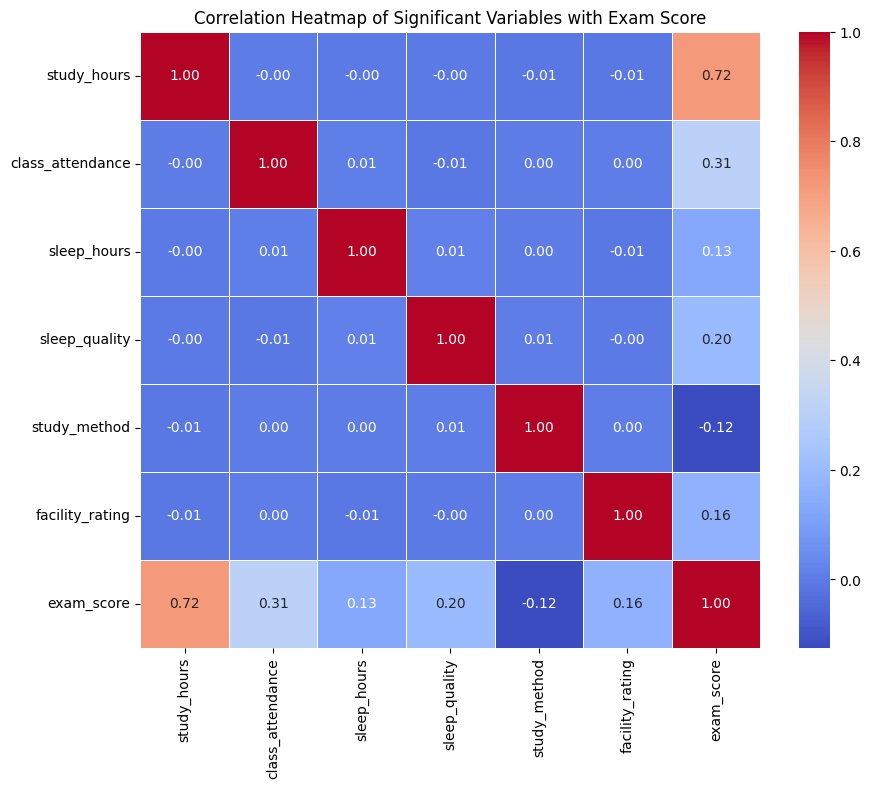

In [16]:
cols_for_heatmap = significant_cols + ['exam_score']
df_corr = df[cols_for_heatmap].copy()

# Convert categorical significant columns to numerical labels for correlation
for col in significant_cols:
    if col in cat_cols:
        df_corr[col], _ = pd.factorize(df_corr[col])

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Significant Variables with Exam Score')
plt.show()

In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Start with the original dataframe (using ALL columns)
df_model = df.copy()

# 2. Ordinal Encode the naturally ordered columns
sleep_map = {'poor': 0, 'average': 1, 'good': 2}
facility_map = {'low': 0, 'medium': 1, 'high': 2}

df_model['sleep_quality'] = df_model['sleep_quality'].map(sleep_map)
df_model['facility_rating'] = df_model['facility_rating'].map(facility_map)

# 3. One-Hot Encode the nominal columns (no natural order)
# drop_first=True prevents the dummy variable trap
nominal_cols = ['gender', 'course', 'internet_access', 'study_method', 'exam_difficulty']
df_model = pd.get_dummies(df_model, columns=nominal_cols, drop_first=True, dtype=int)

# 4. Split the data
X = df_model.drop(['exam_score','student_id'], axis=1)
y = df_model['exam_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

,age,study_hours,class_attendance,sleep_hours,sleep_quality,facility_rating,gender_male,gender_other,course_b.sc,course_b.tech,...,course_bba,course_bca,course_diploma,internet_access_yes,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,exam_difficulty_hard,exam_difficulty_moderate
0,17,2.78,92.9,7.4,0,0,1,0,0,0,...,0,0,1,1,0,0,0,0,1,0
1,23,3.37,64.8,4.6,1,1,0,1,0,0,...,0,1,0,1,0,0,1,0,0,1
2,22,7.88,76.8,8.5,0,2,1,0,1,0,...,0,0,0,1,0,0,0,0,0,1
3,20,0.67,48.4,5.8,1,0,0,1,0,0,...,0,0,1,1,0,0,1,0,0,1
4,20,0.89,71.6,9.8,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,18,6.50,71.3,5.0,2,0,0,1,0,0,...,1,0,0,1,0,0,0,1,0,0
19996,18,3.71,41.6,5.9,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
19997,19,7.88,68.2,4.6,0,0,0,1,0,0,...,0,0,1,1,1,0,0,0,0,0
19998,19,4.60,76.3,6.1,2,1,1,0,0,0,...,1,0,0,0,0,0,0,1,0,1


In [18]:
print("Shapes of the datasets after splitting:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Shapes of the datasets after splitting:
X_train shape: (16000, 22)
X_test shape: (4000, 22)
y_train shape: (16000,)
y_test shape: (4000,)


In [19]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error , mean_squared_error, r2_score

In [20]:
# Initialize the Decision Tree Regressor model
dt_model = DecisionTreeRegressor(random_state=42)

# Train the model on the training data
dt_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = dt_model.predict(X_test)

# Evaluate the model's performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Decision Tree Regressor Model Performance:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Decision Tree Regressor Model Performance:
Mean Absolute Error (MAE): 12.25
Mean Squared Error (MSE): 234.12
R-squared (R2): 0.35


In [21]:
from sklearn.ensemble import AdaBoostRegressor

ada_model = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=3, random_state=42),
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

ada_model.fit(X_train, y_train)

ab_predictions = ada_model.predict(X_test)

ab_mae = mean_absolute_error(y_test, ab_predictions)
ab_rmse = np.sqrt(mean_squared_error(y_test, ab_predictions))
ab_r2 = r2_score(y_test, ab_predictions)

print("AdaBoost Regressor Model Performance:")
print(f"  MAE: {ab_mae:.2f}")
print(f"  RMSE: {ab_rmse:.2f}")
print(f"  R2 Score: {ab_r2:.2f}")

AdaBoost Regressor Model Performance:
  MAE: 8.86
  RMSE: 10.91
  R2 Score: 0.67


In [22]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
xgb_r2 = r2_score(y_test, xgb_predictions)

print("XGBoost Regressor Model Performance:")
print(f"  MAE: {xgb_mae:.2f}")
print(f"  RMSE: {xgb_rmse:.2f}")
print(f"  R2 Score: {xgb_r2:.2f}")

XGBoost Regressor Model Performance:
  MAE: 8.00
  RMSE: 9.90
  R2 Score: 0.73


In [23]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Initialize the base model
xgb_model_base = XGBRegressor(random_state=42)

# 2. Define the hyperparameter distribution grid
# uniform(loc, scale) creates a range from 'loc' to 'loc + scale'
param_dist = {
    'n_estimators': randint(100, 800),             # Number of trees (100 to 800)
    'learning_rate': uniform(0.01, 0.29),          # Step size (0.01 to 0.30)
    'max_depth': randint(3, 10),                   # Maximum depth of the trees
    'min_child_weight': randint(1, 8),             # Minimum data weight required to create a new leaf
    'subsample': uniform(0.6, 0.4),                # Randomly sample 60% to 100% of rows per tree
    'colsample_bytree': uniform(0.6, 0.4),         # Randomly sample 60% to 100% of columns per tree
    'gamma': uniform(0, 0.5)                       # Pruning threshold
}

# 3. Set up RandomizedSearchCV
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_model_base,
    param_distributions=param_dist,
    n_iter=90,                  # Try 50 different random combinations (increase this for better results!)
    cv=5,                       # 5-fold cross validation
    verbose=2,                  # Print progress to the console
    random_state=42,
    n_jobs=-1,                  # Use all available CPU cores to speed up training
    scoring='neg_mean_squared_error'
)

# 4. Run the Search!
print("Starting RandomizedSearchCV for XGBoost...")
random_search_xgb.fit(X_train, y_train)

# 5. Extract the best model and print the parameters
best_xgb_model = random_search_xgb.best_estimator_

print("\nBest XGBoost Parameters Found:")
for key, value in random_search_xgb.best_params_.items():
    print(f"  {key}: {value}")

# 6. Evaluate the mathematically BEST model on your unseen test data
xgb_predictions = best_xgb_model.predict(X_test)

best_xgb_mae = mean_absolute_error(y_test, xgb_predictions)
best_xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
best_xgb_r2 = r2_score(y_test, xgb_predictions)

print("\n--- Optimized XGBoost Regressor Performance ---")
print(f"  MAE: {best_xgb_mae:.2f}")
print(f"  RMSE: {best_xgb_rmse:.2f}")
print(f"  R2 Score: {best_xgb_r2:.2f}")

Starting RandomizedSearchCV for XGBoost...
Fitting 5 folds for each of 90 candidates, totalling 450 fits

Best XGBoost Parameters Found:
  colsample_bytree: 0.6301385024024513
  gamma: 0.15284850964359092
  learning_rate: 0.06536419903360034
  max_depth: 3
  min_child_weight: 3
  n_estimators: 227
  subsample: 0.7490747468376198

--- Optimized XGBoost Regressor Performance ---
  MAE: 7.92
  RMSE: 9.83
  R2 Score: 0.73


In [30]:
import pickle

# 1. Save the Optimized XGBoost Model
with open('best_xgb_model.pkl', 'wb') as file:
    pickle.dump(best_xgb_model, file)

# 2. Save the exact list of expected columns
# This is crucial so our Streamlit app knows exactly how to format the data
expected_columns = X.columns.tolist()
with open('expected_columns.pkl', 'wb') as file:
    pickle.dump(expected_columns, file)

print("✅ Model and Column Data saved successfully as .pkl files!")

✅ Model and Column Data saved successfully as .pkl files!
